<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/jalase_5_6_optimizer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
sgd=keras.optimizers.SGD(decay=1e-3)

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
def func(x):
  return x**2

In [ ]:
def func_grad(x):
  return 2*x

In [ ]:
def gradient_decent(lr,func_grad):
  x=-10
  x_values=[x]
  for i in range(10):
    x-=lr*func_grad(x)
    x_values.append(x)
  print('iteration 10:x:%s'%x)
  return x_values

In [ ]:
def search_path(x_vals,func):
  x_line=np.arange(-15,15,0.01)
  plt.plot(x_line,[func(x) for x in x_line])
  plt.plot(x_vals,[func(x) for x in x_vals],'ro-')

iteration 10:x:-1.0737418240000003


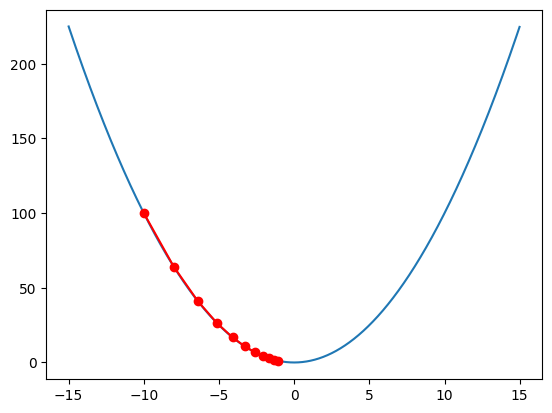

In [ ]:
x_values=gradient_decent(0.1,func_grad)
search_path(x_values,func)

iteration 10:x:-9.801790433519495


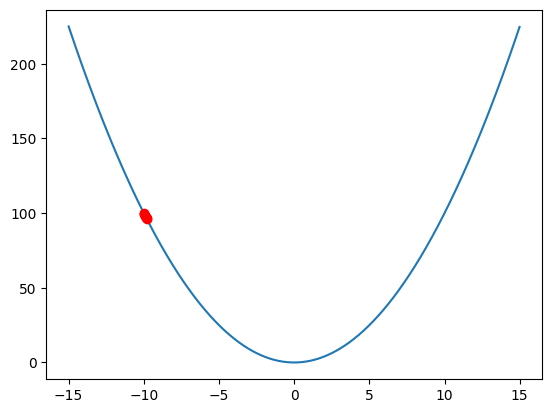

In [ ]:
x_values=gradient_decent(0.001,func_grad)
search_path(x_values,func)

iteration 10:x:-0.060466176000000066


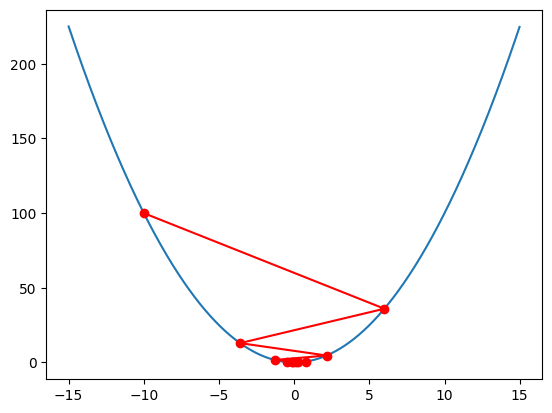

In [ ]:
x_values=gradient_decent(0.8,func_grad)
search_path(x_values,func)

In [ ]:
def func(x1,x2):
  return x1**2+2*x2**2

In [ ]:
def func_grad(x1,x2):
  return (2*x1,4*x2)

In [ ]:
class Optimizers:
  def __init__(self,lr_schedule,rate=0.01):
    self.lr_schedule=self.lr(lr_schedule,rate)
  def lr(self,lr_schedule,rate):
    if lr_schedule=="constant":
      return self.constant_lr(rate)
  def constant_lr(self,rate):
    return rate
  def gradient_decent(self,x1,x2,t1,t2,func_grad):
    gr_x1,gr_x2=func_grad(x1,x2)
    return x1-self.lr_schedule*gr_x1,x2-self.lr_schedule*gr_x2,0,0
  def stochastic_gradient_decesnt(self,x1,x2,t1,t2,func_grad):
    gr_x1,gr_x2=func_grad(x1,x2)
    gr_x1+=np.random.normal(0,1)
    gr_x2+=np.random.normal(0,1)
    return x1-self.lr_schedule*gr_x1,x2-self.lr_schedule*gr_x2,0,0
  def gradient_decent_with_momentum(self,x1,x2,v1,v2,func_grad):
    alpha=0.9
    gr_x1,gr_x2=func_grad(x1,x2)
    v1=alpha*v1-self.lr_schedule*gr_x1
    v2=alpha*v2-self.lr_schedule*gr_x2
    return x1+v1,x2+v2,v1,v2
  def nesterov_gradient_decent_with_momentum(self,x1,x2,v1,v2,func_grad):
    alpha=0.9
    x1+=alpha*v1
    x2+=alpha*v2
    gr_x1,gr_x2=func_grad(x1,x2)
    v1=alpha*v1-self.lr_schedule*gr_x1
    v2=alpha*v2-self.lr_schedule*gr_x2
    return x1+v1,x2+v2,v1,v2
  def ada_grad(self,x1,x2,r1,r2,func_grad):
    delta=1e-7
    gr_x1,gr_x2=func_grad(x1,x2)
    r1+=gr_x1**2
    r2+=gr_x2**2
    x1-=self.lr_schedule/(delta+np.sqrt(r1)*gr_x1)
    x2-=self.lr_schedule/(delta+np.sqrt(r2)*gr_x2)
    return x1,x2,r1,r2
  def rmsprop(self,x1,x2,r1,r2,func_grad):
    delta=1e-7
    rho=0.7
    gr_x1,gr_x2=func_grad(x1,x2)
    r1=r1*rho+(1-rho)*gr_x1**2
    r2=r2*rho+(1-rho)*gr_x2**2
    x1-=self.lr_schedule/(delta+np.sqrt(delta+r1))*gr_x1
    x2-=self.lr_schedule/(delta+np.sqrt(delta+r2))*gr_x2
    return x1,x2,r1,r2
  def adam(self,x1,x2,s1,s2,r1,r2,t,func_grad):
    delta,rho1,rho2=1e-8,0.9,0.999
    gr_x1,gr_x2=func_grad(x1,x2)
    s1=rho1*s1+(1-rho1)*gr_x1
    s2=rho1*s2+(1-rho1)*gr_x2

    r1=rho2*r1+(1-rho2)*gr_x1**2
    r2=rho2*r2+(1-rho2)*gr_x2**2

    shat1=s1/(1-rho1**(t+1))
    shat2=s2/(1-rho1**(t+1))

    rhat1=r1/(1-rho2**(t+1))
    rhat2=r2/(1-rho2**(t+1))

    x1-=self.lr_schedule*shat1/(delta+np.sqrt(rhat1))
    x2-=self.lr_schedule*shat2/(delta+np.sqrt(rhat2))
    return x1,x2,r1,r2,s1,s2



In [ ]:
def search_adam(optimizer_adam, func_grad, iteration=20):
  x1,x2,s1,r1,r2=-5,-2,0,0,0,0
  x_iterations=[(x1,x2)]
  for t in range(iteration):
    x1,x2,s1,s2,r1,r2=optimizer_adam(x1,x2,s1,s2,r1,r2,t,func_grad)
    x_iterations.append((x1,x2))
    print('epoch{},x1:{},x2:{}'.format(t+1,x1,x2))
    return x_iterations

In [ ]:
def search(optimizer,func_grad,iteration=20):
  x1,x2,t1,t2=-5,-2,0,0
  x_iterations=[(x1,x2)]
  for i in range(iteration):
    x1,x2,t1,t2=optimizer(x1,x2,t1,t2,func_grad)
    x_iterations.append((x1,x2))
    print('epoch{},x1:{}, x2:{}'.format(i+1,x1,x2))
  return x_iterations

In [ ]:
def search_path(func,x_iterations):
  x_line=np.arange(-15,15,0.01)
  plt.plot(*zip(*x_iterations),'-o',color='red')
  x1,x2=np.meshgrid(np.arange(-5.5,5.5,0.1),np.arange(-5.5,5.5,0.1))
  plt.contourf(x1,x2,func(x1,x2))
  plt.xlabel('x1')
  plt.xlabel('y1')


epoch1,x1:-4.0, x2:-1.2
epoch2,x1:-3.2, x2:-0.72
epoch3,x1:-2.56, x2:-0.432
epoch4,x1:-2.048, x2:-0.2592
epoch5,x1:-1.6384, x2:-0.15552
epoch6,x1:-1.31072, x2:-0.09331199999999999
epoch7,x1:-1.0485760000000002, x2:-0.055987199999999994
epoch8,x1:-0.8388608000000002, x2:-0.033592319999999995
epoch9,x1:-0.6710886400000001, x2:-0.020155391999999994
epoch10,x1:-0.5368709120000001, x2:-0.012093235199999997
epoch11,x1:-0.4294967296000001, x2:-0.007255941119999998
epoch12,x1:-0.3435973836800001, x2:-0.004353564671999998
epoch13,x1:-0.27487790694400005, x2:-0.0026121388031999987
epoch14,x1:-0.21990232555520003, x2:-0.0015672832819199991
epoch15,x1:-0.17592186044416003, x2:-0.0009403699691519995
epoch16,x1:-0.140737488355328, x2:-0.0005642219814911997
epoch17,x1:-0.11258999068426241, x2:-0.00033853318889471976
epoch18,x1:-0.09007199254740993, x2:-0.00020311991333683184
epoch19,x1:-0.07205759403792794, x2:-0.0001218719480020991
epoch20,x1:-0.057646075230342354, x2:-7.312316880125945e-05


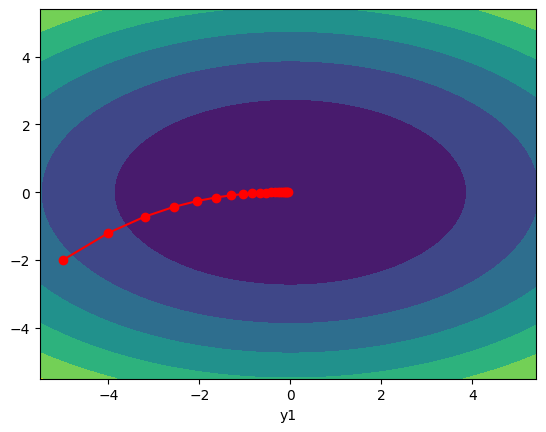

In [ ]:
opt=Optimizers('constant',0.1)
search_path(func, search(opt.gradient_decent,func_grad))

epoch1,x1:-4.027617486087149, x2:-1.3338062150065664
epoch2,x1:-3.0915075158117107, x2:-0.858469580842258
epoch3,x1:-2.4360877411436705, x2:-0.5054846071724519
epoch4,x1:-1.9989795482397144, x2:-0.29689096897844924
epoch5,x1:-1.5057297364551372, x2:-0.23911228698690948
epoch6,x1:-1.0382867520056325, x2:-0.22583972186686843
epoch7,x1:-0.8968184578141961, x2:0.16752425784144595
epoch8,x1:-0.7168250758074877, x2:0.008279638935484446
epoch9,x1:-0.6084806699369906, x2:0.11427946031604806
epoch10,x1:-0.5423365286730213, x2:0.1932679885710028
epoch11,x1:-0.31541170784814887, x2:0.09741901770839745
epoch12,x1:-0.28435116177582903, x2:-0.04928035381286114
epoch13,x1:-0.34286433198973293, x2:0.08083249270651596
epoch14,x1:-0.2659623484679168, x2:0.09190398304205982
epoch15,x1:-0.23061059784045324, x2:-0.0731733868133452
epoch16,x1:-0.035430016884872656, x2:-0.12718207374408766
epoch17,x1:-0.12066302764850648, x2:0.0038110762308840307
epoch18,x1:0.09690600016664677, x2:-0.026370848617545142
epoch

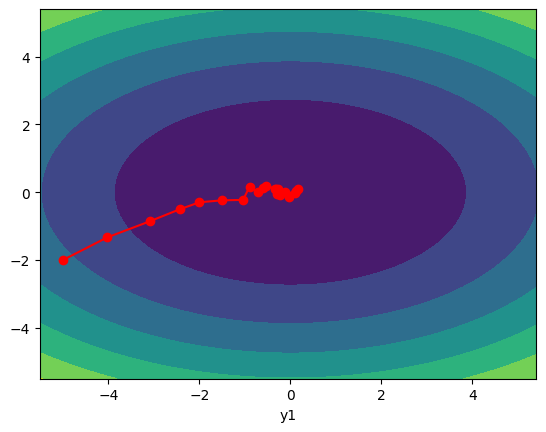

In [ ]:
opt=Optimizers('constant',0.1)
search_path(func, search(opt.stochastic_gradient_decesnt,func_grad))

epoch1,x1:-4.9, x2:-1.92
epoch2,x1:-4.712000000000001, x2:-1.7711999999999999
epoch3,x1:-4.4485600000000005, x2:-1.5664319999999998
epoch4,x1:-4.122492800000001, x2:-1.31948352
epoch5,x1:-3.7465824640000007, x2:-1.0444505471999999
epoch6,x1:-3.333331512320001, x2:-0.7551428497919999
epoch7,x1:-2.894739025561601, x2:-0.4645602081331199
epoch8,x1:-2.4421110069678087, x2:-0.18445342231480305
epoch9,x1:-1.9859035700940395, x2:0.07502082181427427
epoch10,x1:-1.5355988055057666, x2:0.30554680865787287
epoch11,x1:-1.0996125412662057, x2:0.5007983244707968
epoch12,x1:-0.6852326526252766, x2:0.6564927557235963
epoch13,x1:-0.29858609979593487, x2:0.7703580336221721
epoch14,x1:0.05536751974639137, x2:0.8420224623860034
epoch15,x1:0.3728184269395572, x2:0.8728395497780115
epoch16,x1:0.6510678748746153, x2:0.8656613464396983
epoch17,x1:0.8884710205186752, x2:0.8245745095776285
epoch18,x1:1.0843644311879557, x2:0.7546133760186604
epoch19,x1:1.238981212166549, x2:0.6614638207748428
epoch20,x1:1.35335

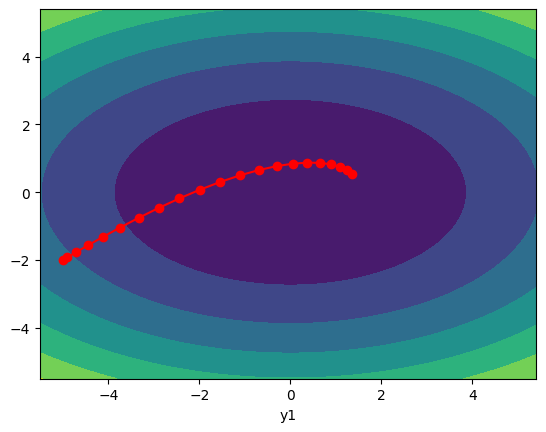

In [ ]:
opt=Optimizers('constant',0.01)
search_path(func, search(opt.gradient_decent_with_momentum,func_grad))

epoch1,x1:-4.9, x2:-1.92
epoch2,x1:-4.6238, x2:-1.7020799999999998
epoch3,x1:-4.1995156, x2:-1.3765939199999997
epoch4,x1:-3.6580780471999996, x2:-0.9790353100799997
epoch5,x1:-3.031777283886399, x2:-0.5468258775859197
epoch6,x1:-2.352899060116476, x2:-0.11627862164471786
epoch7,x1:-1.6524984944391192, x2:0.2800510839473624
epoch8,x1:-0.9593430425408113, x2:0.6154639366002351
epoch9,x1:-0.2990481002157834, x2:0.8705602448062028
epoch10,x1:0.30658117568494153, x2:1.0339843435863023
epoch11,x1:0.8399974393195662, x2:1.102483222375833
epoch12,x1:1.2881521738965849, x2:1.0803434883858472
epoch13,x1:1.6425416524078316, x2:0.9783116226775356
epoch14,x1:1.899075600276456, x2:0.8121312602165625
epoch15,x1:2.0577912805477125, x2:0.6008469582252278
epoch16,x1:2.1224393241310304, x2:0.3650267176079093
epoch17,x1:2.0999698690390374, x2:0.12504647051412152
epoch18,x1:1.9999485044327603, x2:-0.10043928362936072
epoch19,x1:1.833931233118666, x2:-0.2957430768026633
epoch20,x1:1.6148263020774718, x2:-0

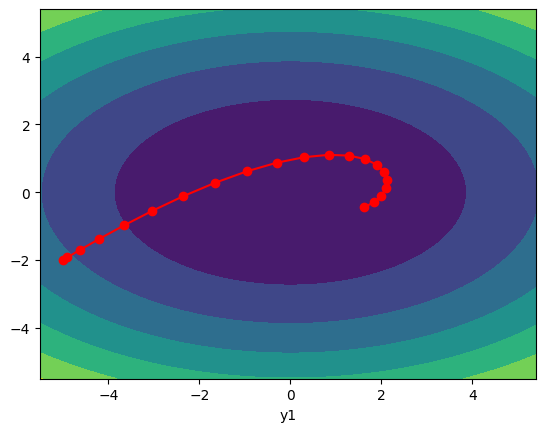

In [ ]:
opt=Optimizers('constant',0.01)
search_path(func, search(opt.nesterov_gradient_decent_with_momentum,func_grad))

epoch1,x1:-4.9998999999999, x2:-1.999843749999756
epoch2,x1:-4.999829287200365, x2:-1.9997332516164656
epoch3,x1:-4.9997715491601005, x2:-1.9996430222423904
epoch4,x1:-4.999721545627473, x2:-1.9995648756765123
epoch5,x1:-4.999676820386036, x2:-1.9994949748527924
epoch6,x1:-4.999635991419914, x2:-1.999431160798708
epoch7,x1:-4.999598190638739, x2:-1.9993720773882997
epoch8,x1:-4.9995628308081494, x2:-1.999316807245695
epoch9,x1:-4.999529492853357, x2:-1.9992646956925324
epoch10,x1:-4.999497865345852, x2:-1.9992152562148373
epoch11,x1:-4.999467709386677, x2:-1.999168115604033
epoch12,x1:-4.999438836966934, x2:-1.9991229801518848
epoch13,x1:-4.999411096979078, x2:-1.9990796137974278
epoch14,x1:-4.999384365813077, x2:-1.9990378234363242
epoch15,x1:-4.999358540825143, x2:-1.9989974487177458
epoch16,x1:-4.999333535674585, x2:-1.998958354759604
epoch17,x1:-4.999309276914635, x2:-1.998920426822743
epoch18,x1:-4.999285701448297, x2:-1.9988835663364684
epoch19,x1:-4.999262754595251, x2:-1.998847

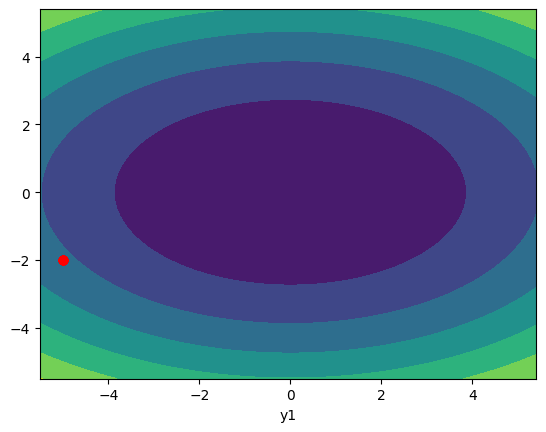

In [ ]:
opt=Optimizers('constant',0.01)
search_path(func, search(opt.ada_grad,func_grad))

epoch1,x1:-4.999817425814136, x2:-1.9997147278345617
epoch2,x1:-4.99967738968453, x2:-1.9994958844977517
epoch3,x1:-4.999554004446797, x2:-1.9993030358440633
epoch4,x1:-4.999439271902627, x2:-1.9991236884103165
epoch5,x1:-4.999329614092182, x2:-1.9989522528909238
epoch6,x1:-4.999223131172761, x2:-1.9987857611793134
epoch7,x1:-4.999118711922268, x2:-1.998622477035661
epoch8,x1:-4.999015666466497, x2:-1.9984613224259355
epoch9,x1:-4.9989135496933335, x2:-1.9983016016989639
epoch10,x1:-4.998812066964583, x2:-1.998142854305832
epoch11,x1:-4.998711019840143, x2:-1.9979847700154383
epoch12,x1:-4.998610273077397, x2:-1.9978271373605938
epoch13,x1:-4.998509733749378, x2:-1.997669811013307
epoch14,x1:-4.998409337642918, x2:-1.9975126905317018
epoch15,x1:-4.998309040211719, x2:-1.9973557062223395
epoch16,x1:-4.998208810468264, x2:-1.9971988095937987
epoch17,x1:-4.998108626815685, x2:-1.9970419668413155
epoch18,x1:-4.9980084741818755, x2:-1.9968851543663213
epoch19,x1:-4.997908342038432, x2:-1.99

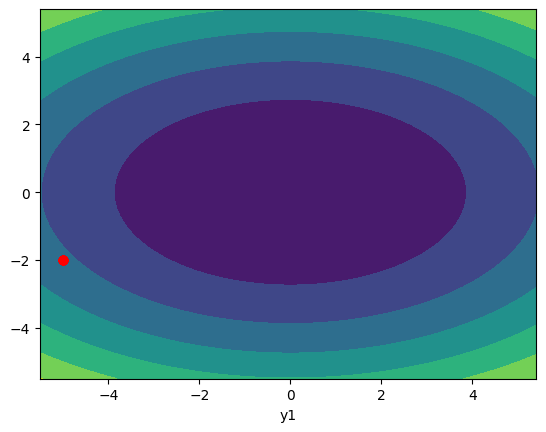

In [ ]:
opt=Optimizers('constant',0.01)
search_path(func, search(opt.rmsprop,func_grad))

In [ ]:
opt=Optimizers('constant',0.01)
search_path(func, search(opt.adam,func_grad))

TypeError: Optimizers.adam() missing 3 required positional arguments: 'r2', 't', and 'func_grad'